In [87]:
import string
import numpy as np
from PIL import Image
import os
import pickle
import time
import matplotlib.pyplot as plt
from tqdm import tqdm

# PyTorch imports (replacements for TensorFlow/Keras)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
# from torchvision.models import Xception_Weights
import timm

# For text processing
from collections import Counter
import re

In [ ]:
model = timm.create_model('xception', pretrained=True)

/Users/ankitpokhrel/Downloads/All_projects/ml_projects/myenv/lib/python3.12/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


In [89]:
from tqdm.notebook import tqdm
tqdm.pandas()

In [90]:
#Reads a text file and returns its contents as a string
def load_doc(filename):
    # Opening the file as read only
    file = open(filename, 'r')
    text = file.read()
    file.close()
    return text

In [91]:
# Parses file with format: image_id.jpg#0\tcaption
# Groups multiple captions per image into a dictionary
# Returns: {image_id: [caption1, caption2, ...]}
def all_img_captions(filename):
    file = load_doc(filename)
    captions = file.split('\n')
    descriptions ={}
    for caption in captions[:-1]:
        img, caption = caption.split('\t')
        if img[:-2] not in descriptions:
            descriptions[img[:-2]] = [ caption ]
        else:
            descriptions[img[:-2]].append(caption)
    return descriptions

In [92]:
# Cleans caption text:
# - Lowercase everything
# - Remove punctuation
# - Remove words with length ≤ 1
# - Remove words containing numbers
# Returns cleaned captions dictionary
def cleaning_text(captions):
    table = str.maketrans('','',string.punctuation)
    for img,caps in captions.items():
        for i,img_caption in enumerate(caps):

            img_caption.replace("-"," ")
            desc = img_caption.split()

            #converts to lowercase
            desc = [word.lower() for word in desc]
            #remove punctuation from each token
            desc = [word.translate(table) for word in desc]
            #remove hanging 's and a 
            desc = [word for word in desc if(len(word)>1)]
            #remove tokens with numbers in them
            desc = [word for word in desc if(word.isalpha())]
            #convert back to string

            img_caption = ' '.join(desc)
            captions[img][i]= img_caption
    return captions

In [93]:
# Builds a set of all unique words across all captions
# Returns: {word1, word2, word3, ...}
def text_vocabulary(descriptions):
    # build vocabulary of all unique words
    vocab = set()
    for key in descriptions.keys():
        [vocab.update(d.split()) for d in descriptions[key]]
    return vocab

#it's just the vocabulary of all unique words present in the entire dataset.

In [94]:
# Saves cleaned captions to file
# Format: image_id\tcaption (one per line)
def save_descriptions(descriptions, filename):
    lines = list()
    for key, desc_list in descriptions.items():
        for desc in desc_list:
            lines.append(key + '\t' + desc )
    data = "\n".join(lines)
    file = open(filename,"w")
    file.write(data)
    file.close()

In [95]:
dataset_text = "/Users/ankitpokhrel/Downloads/All_projects/ml_projects/image_captioning/Flickr8k_text"
dataset_images = "/Users/ankitpokhrel/Downloads/All_projects/ml_projects/image_captioning/Flicker8k_Dataset"

In [96]:
# we prepare our text data
filename = dataset_text + "/" + "Flickr8k.token.txt"
#loading the file that contains all data
#mapping them into descriptions dictionary img to 5 captions
descriptions = all_img_captions(filename)
print("Length of descriptions =" ,len(descriptions))

#cleaning the descriptions
clean_descriptions = cleaning_text(descriptions)

#building vocabulary 
vocabulary = text_vocabulary(clean_descriptions)
print("Length of vocabulary = ", len(vocabulary))

#saving each description to file 
save_descriptions(clean_descriptions, "descriptions.txt")

Length of descriptions = 8092
Length of vocabulary =  8763


In [97]:
# #Removes the final classification layer for transfer learning
# With classifier: "This is 80% a golden retriever"
# Without classifier: "There's a furry animal, grass, trees, sunny day, outdoor scene..." (rich features your LSTM needs)
model = nn.Sequential(*list(model.children())[:-1])

In [98]:
from pickle import dump, load

In [22]:
def extract_features(directory, model, device='cpu'):
    model.eval()  # Set to evaluation mode
    features = {}
    valid_images = ['.jpg', '.jpeg', '.png']
    
    for img in tqdm(os.listdir(directory)):
        ext = os.path.splitext(img)[1].lower()
        if ext not in valid_images:
            continue
            
        filename = os.path.join(directory, img)
        image = Image.open(filename).convert('RGB')
        image = image.resize((299, 299))
        
        # Convert to tensor and normalize
        image = np.array(image)
        image = image / 127.5 - 1.0  # Normalize to [-1, 1]
        image = torch.tensor(image).permute(2, 0, 1).float()  # (H,W,C) -> (C,H,W)
        image = image.unsqueeze(0).to(device)  # Add batch dim: (1, C, H, W)
        
        # Extract features
        with torch.no_grad():  # No gradients needed for inference
            feature = model(image)  # Use model() not model.predict()
        
        features[img] = feature.cpu().numpy()  # Convert to numpy
        
    return features

# Usage
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)
features = extract_features(dataset_images, model, device)

  0%|          | 0/8091 [00:00<?, ?it/s]

NameError: name 'dump' is not defined

In [53]:
dump(features, open("features.p", "wb"))

features = load(open("features.p","rb"))

In [99]:
#load the data 
def load_photos(filename):
    file = load_doc(filename)
    photos = file.split("\n")[:-1]
    photos_present = [photo for photo in photos if os.path.exists(os.path.join(dataset_images, photo))]
    return photos_present


In [100]:
def load_clean_descriptions(filename, photos): 
    #loading clean_descriptions
    file = load_doc(filename)
    descriptions = {}
    for line in file.split("\n"):

        words = line.split()
        if len(words)<1 :
            continue

        image, image_caption = words[0], words[1:]

        if image in photos:
            if image not in descriptions:
                descriptions[image] = []
            desc = '<start> ' + " ".join(image_caption) + ' <end>'
            descriptions[image].append(desc)

    return descriptions
# Why <start> and <end>?

# <start>: Signals LSTM to begin caption generation
# <end>: Signals LSTM when to stop generating

In [101]:
def load_features(photos):
    #loading all features
    all_features = load(open("features.p","rb"))
    #selecting only needed features
    features = {k:all_features[k] for k in photos}
    return features

In [102]:
filename = dataset_text + "/" + "Flickr_8k.trainImages.txt"

In [103]:
#train = loading_data(filename)

train_imgs = load_photos(filename)
train_descriptions = load_clean_descriptions("descriptions.txt", train_imgs)
train_features = load_features(train_imgs)


In [104]:
#converting dictionary to clean list of descriptions
# Why? Tokenizer needs a flat list of all captions
def dict_to_list(descriptions):
    all_desc = []
    for key in descriptions.keys():
        [all_desc.append(d) for d in descriptions[key]]
    return all_desc

In [105]:
class Tokenizer:
    def __init__(self):
        self.word_to_idx = {}
        self.idx_to_word = {}
        self.vocab_size = 0
    
    def fit_on_texts(self, texts):
        vocab = set()
        for text in texts:
            vocab.update(text.split())
        
        self.word_to_idx = {'<pad>': 0, '<start>': 1, '<end>': 2, '<unk>': 3}
        
        for idx, word in enumerate(sorted(vocab), start=4):
            self.word_to_idx[word] = idx
        
        self.idx_to_word = {v: k for k, v in self.word_to_idx.items()}
        self.vocab_size = len(self.word_to_idx)
    
    # Add this property to match Keras API
    @property
    def word_index(self):
        return self.word_to_idx
    
    def texts_to_sequences(self, texts):
        sequences = []
        for text in texts:
            seq = [self.word_to_idx.get(word, self.word_to_idx['<unk>']) 
                   for word in text.split()]
            sequences.append(seq)
        return sequences

In [106]:
#creating tokenizer class 
#this will vectorise text corpus
#each integer will represent token in dictionary
def create_tokenizer(descriptions):
    desc_list = dict_to_list(descriptions)
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(desc_list)
    return tokenizer

In [107]:
# give each word an index, and store that into tokenizer.p pickle file
tokenizer = create_tokenizer(train_descriptions)
dump(tokenizer, open('tokenizer.p', 'wb'))
vocab_size = len(tokenizer.word_index) + 1
print(vocab_size)

7581


In [108]:
def max_length(descriptions):
    desc_list = dict_to_list(descriptions)
    return max(len(d.split()) for d in desc_list)
    
max_length = max_length(train_descriptions)
print(max_length)

34


In [124]:
import torch
from torch.utils.data import Dataset, DataLoader

class CaptionDataset(Dataset):
    """PyTorch Dataset for image captioning"""
    def __init__(self, descriptions, features, tokenizer, max_length, vocab_size):
        self.descriptions = descriptions
        self.features = features
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.vocab_size = vocab_size
        self.samples = []
        
        # Pre-generate all samples
        for key, description_list in descriptions.items():
            feature = features[key][0]
            input_image, input_sequence, output_word = create_sequences(
                tokenizer, max_length, description_list, feature, vocab_size
            )
            for i in range(len(input_image)):
                self.samples.append({
                    'image': input_image[i],
                    'sequence': input_sequence[i],
                    'target': output_word[i]
                })
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        return (
            torch.tensor(sample['image'], dtype=torch.float32),
            torch.tensor(sample['sequence'], dtype=torch.long),
            torch.tensor(sample['target'], dtype=torch.long)  # Fixed: changed to long
        )

# Create DataLoader
def create_data_loader(descriptions, features, tokenizer, max_length, vocab_size, batch_size=32):
    dataset = CaptionDataset(descriptions, features, tokenizer, max_length, vocab_size)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return dataloader

In [125]:
def create_sequences(tokenizer, max_length, desc_list, feature, vocab_size):
    X1, X2, y = [], [], []
    
    for desc in desc_list:
        seq = tokenizer.texts_to_sequences([desc])[0]
        
        # Skip entire sequence if any token is out of range
        if any(token >= vocab_size for token in seq):
            continue
            
        for i in range(1, len(seq)):
            in_seq = seq[:i]
            out_seq = seq[i]
            
            # Pad input
            in_seq = in_seq + [0] * (max_length - len(in_seq))
            in_seq = in_seq[:max_length]
            
            X1.append(feature)
            X2.append(in_seq)
            y.append(out_seq)  # Just index, NOT one-hot
    
    return np.array(X1), np.array(X2), np.array(y)

In [126]:
# Create DataLoader
train_loader = create_data_loader(
    train_descriptions, 
    train_features, 
    tokenizer, 
    max_length, 
    vocab_size, 
    batch_size=32
)

# Check shapes
for image_features, input_seq, target in train_loader:
    print(f"Image features shape: {image_features.shape}")  # (batch_size, 2048)
    print(f"Input sequence shape: {input_seq.shape}")       # (batch_size, max_length)
    print(f"Target shape: {target.shape}")                  # (batch_size, vocab_size)
    break

Image features shape: torch.Size([32, 2048])
Input sequence shape: torch.Size([32, 34])
Target shape: torch.Size([32])


In [127]:
import torch
import torch.nn as nn

class ImageCaptioningModel(nn.Module):
    def __init__(self, vocab_size, max_length, embed_dim=256, hidden_dim=256, dropout=0.5):
        super(ImageCaptioningModel, self).__init__()
        
        # Image feature branch
        self.image_dropout = nn.Dropout(dropout)
        self.image_fc = nn.Linear(2048, embed_dim)
        
        # Caption sequence branch
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.seq_dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        
        # Decoder (merge + output)
        self.decoder_fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.decoder_fc2 = nn.Linear(hidden_dim, vocab_size)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, image_features, input_seq):
        """
        Args:
            image_features: (batch_size, 2048)
            input_seq: (batch_size, max_length)
        Returns:
            outputs: (batch_size, vocab_size)
        """
        # Image branch
        img_feat = self.image_dropout(image_features)
        img_feat = self.image_fc(img_feat)  # (batch, 256)
        img_feat = self.relu(img_feat)
        
        # Sequence branch
        seq_embed = self.embedding(input_seq)  # (batch, max_length, 256)
        seq_embed = self.seq_dropout(seq_embed)
        lstm_out, (hidden, cell) = self.lstm(seq_embed)  # hidden: (1, batch, 256)
        lstm_feat = hidden.squeeze(0)  # (batch, 256)
        
        # Merge (add image and LSTM features)
        merged = img_feat + lstm_feat  # (batch, 256)
        
        # Decoder
        decoded = self.decoder_fc1(merged)  # (batch, 256)
        decoded = self.relu(decoded)
        outputs = self.decoder_fc2(decoded)  # (batch, vocab_size)
        
        return outputs

# Initialize model
model = ImageCaptioningModel(vocab_size, max_length)

# Move to device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss(ignore_index=0)  # Ignore padding
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Model summary
print(model)

ImageCaptioningModel(
  (image_dropout): Dropout(p=0.5, inplace=False)
  (image_fc): Linear(in_features=2048, out_features=256, bias=True)
  (embedding): Embedding(7581, 256, padding_idx=0)
  (seq_dropout): Dropout(p=0.5, inplace=False)
  (lstm): LSTM(256, 256, batch_first=True)
  (decoder_fc1): Linear(in_features=256, out_features=256, bias=True)
  (decoder_fc2): Linear(in_features=256, out_features=7581, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
)


In [128]:
import os

# Print dataset info
print('Dataset: ', len(train_imgs))
print('Descriptions: train=', len(train_descriptions))
print('Photos: train=', len(train_features))
print('Vocabulary Size:', vocab_size)
print('Description Length: ', max_length)

# Initialize model
model = ImageCaptioningModel(vocab_size, max_length)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Create DataLoader
train_loader = create_data_loader(
    train_descriptions, 
    train_features, 
    tokenizer, 
    max_length, 
    vocab_size, 
    batch_size=32
)

# Training parameters
epochs = 10

# Create directory for saving models
os.makedirs("models2", exist_ok=True)

Dataset:  6000
Descriptions: train= 6000
Photos: train= 6000
Vocabulary Size: 7581
Description Length:  34


In [129]:
# Recreate DataLoader with fixed CaptionDataset
train_loader = create_data_loader(
    train_descriptions, 
    train_features, 
    tokenizer, 
    max_length, 
    vocab_size, 
    batch_size=32
)

print("DataLoader recreated with fixed target dtype!")

# Verify the fix
for image_features, input_seq, target in train_loader:
    print(f"Target dtype: {target.dtype}")  # Should be torch.int64 (Long)
    break

DataLoader recreated with fixed target dtype!
Target dtype: torch.int64


In [130]:
# Training loop
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    
    for batch_idx, (image_features, input_seq, target) in enumerate(train_loader):
        # Move to device
        image_features = image_features.to(device)
        input_seq = input_seq.to(device)
        target = target.to(device)
        
        # Forward pass
        outputs = model(image_features, input_seq)
        
        # Calculate loss
        loss = criterion(outputs, target)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        # Print progress every 100 batches
        if (batch_idx + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Step [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}')
    
    # Print epoch summary
    avg_loss = epoch_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{epochs}] completed, Average Loss: {avg_loss:.4f}')
    
    # Save model
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_loss,
    }, f'models2/model_{epoch}.pth')
    
    print(f'Model saved: models2/model_{epoch}.pth')

print('Training completed!')

Epoch [1/10], Step [100/9575], Loss: 6.0542
Epoch [1/10], Step [200/9575], Loss: 5.6956
Epoch [1/10], Step [300/9575], Loss: 6.4867
Epoch [1/10], Step [400/9575], Loss: 5.7333
Epoch [1/10], Step [500/9575], Loss: 5.4103
Epoch [1/10], Step [600/9575], Loss: 6.1962
Epoch [1/10], Step [700/9575], Loss: 5.4716
Epoch [1/10], Step [800/9575], Loss: 5.9347
Epoch [1/10], Step [900/9575], Loss: 6.4313
Epoch [1/10], Step [1000/9575], Loss: 5.4391
Epoch [1/10], Step [1100/9575], Loss: 5.7472
Epoch [1/10], Step [1200/9575], Loss: 6.0798
Epoch [1/10], Step [1300/9575], Loss: 5.5342
Epoch [1/10], Step [1400/9575], Loss: 4.9590
Epoch [1/10], Step [1500/9575], Loss: 5.6997
Epoch [1/10], Step [1600/9575], Loss: 5.7413
Epoch [1/10], Step [1700/9575], Loss: 5.1656
Epoch [1/10], Step [1800/9575], Loss: 5.2465
Epoch [1/10], Step [1900/9575], Loss: 4.8966
Epoch [1/10], Step [2000/9575], Loss: 5.5954
Epoch [1/10], Step [2100/9575], Loss: 6.4200
Epoch [1/10], Step [2200/9575], Loss: 5.4527
Epoch [1/10], Step 

## Testing Model Performance

In [141]:
import torch
import argparse
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from pickle import load

In [202]:
# Set image path directly for notebook environment
img_path = "/Users/ankitpokhrel/Downloads/All_projects/ml_projects/image_captioning/Flicker8k_Dataset/3437273677_47d4462974.jpg"
# print(f"Selected image: {img_path}")

In [212]:
# # List available images in the dataset
# import os
# available_images = [img for img in os.listdir(dataset_images) if img.endswith(('.jpg', '.jpeg', '.png'))]
# print(f"Total images available: {len(available_images)}")
# print("First 10 images:")
# for i, img in enumerate(available_images[:10]):
#     print(f"{i+1}. {img}")

# Use the first image as default (you can change the index)
img_path = os.path.join(dataset_images, available_images[1101])
print(f"\nUsing image: {img_path}")


Using image: /Users/ankitpokhrel/Downloads/All_projects/ml_projects/image_captioning/Flicker8k_Dataset/2714878018_1593c38d69.jpg


In [213]:
def extract_features(filename, model, device):
    """Extract features from image using Xception"""
    try:
        image = Image.open(filename).convert('RGB')
    except:
        print("ERROR: Couldn't open image! Make sure the image path and extension is correct")
        return None
    
    image = image.resize((299, 299))
    image = np.array(image)
    
    # Normalize
    image = image / 127.5 - 1.0
    
    # Convert to tensor
    image = torch.tensor(image).permute(2, 0, 1).float()  # (H,W,C) -> (C,H,W)
    image = image.unsqueeze(0).to(device)  # (1, C, H, W)
    
    # Extract features
    model.eval()
    with torch.no_grad():
        feature = model(image)
    
    return feature

In [214]:
def extract_single_image_features(image_path, model, device='cpu'):
    """Extract features from a single image for inference"""
    model.eval()
    
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    image = image.resize((299, 299))
    
    # Convert to tensor and normalize
    image = np.array(image)
    image = image / 127.5 - 1.0  # Normalize to [-1, 1]
    image = torch.tensor(image).permute(2, 0, 1).float()  # (H,W,C) -> (C,H,W)
    image = image.unsqueeze(0).to(device)  # Add batch dim: (1, C, H, W)
    
    # Extract features
    with torch.no_grad():
        feature = model(image)
    
    return feature

In [215]:
def word_for_id(integer, tokenizer):
    """Convert integer back to word using tokenizer"""
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

def generate_caption(model, tokenizer, photo, max_length, device):
    """Generate caption for image"""
    model.eval()
    
    in_text = '<start>'
    
    for i in range(max_length):
        # Tokenize current sequence
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        
        # Pad sequence
        sequence = sequence + [0] * (max_length - len(sequence))
        sequence = sequence[:max_length]
        sequence = torch.tensor([sequence], dtype=torch.long).to(device)
        
        # Ensure photo is tensor and has correct shape
        if isinstance(photo, dict):
            # Extract from dictionary if needed
            photo_tensor = list(photo.values())[0]
        else:
            photo_tensor = photo
            
        if len(photo_tensor.shape) == 3:
            photo_tensor = photo_tensor.unsqueeze(0)  # Add batch dimension
            
        photo_tensor = torch.tensor(photo_tensor, dtype=torch.float32).to(device)
        
        # Predict next word
        with torch.no_grad():
            pred = model(photo_tensor, sequence)
            pred = torch.argmax(pred, dim=1).item()
        
        # Convert index to word
        word = word_for_id(pred, tokenizer)
        
        if word is None or word == '<end>':
            break
        
        in_text += ' ' + word
    
    # Clean up the output
    caption = in_text.replace('<start>', '').strip()
    return caption

In [216]:

# Load tokenizer
tokenizer = load(open("tokenizer.p", "rb"))
vocab_size = len(tokenizer.word_index) + 1
max_length = 32

# Load feature extractor (Xception)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
xception_model = timm.create_model('xception', pretrained=True, num_classes=0)
xception_model = xception_model.to(device)


In [217]:
# Load captioning model
model = ImageCaptioningModel(vocab_size, max_length)
checkpoint = torch.load('models2/model_9.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

# Extract features from input image
photo = extract_single_image_features(img_path, xception_model, device)

# Generate caption
description = generate_caption(model, tokenizer, photo, max_length, device)

/var/folders/4j/n0rl6b3s0657t_7z21qxxz6w0000gn/T/ipykernel_60274/561320077.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  photo_tensor = torch.tensor(photo_tensor, dtype=torch.float32).to(device)





two boys are playing in the water


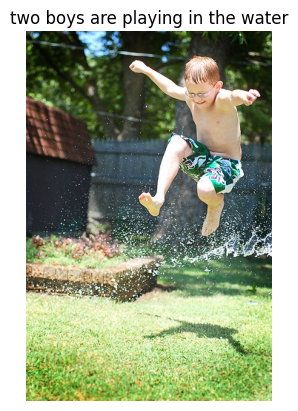

In [218]:
# Display result
print("\n\n")
print(description)
img = Image.open(img_path)
plt.imshow(img)
plt.axis('off')
plt.title(description)
plt.show()